# Graph Neural Networks (GNN)

## 1. Definition

**Graph Neural Networks (GNNs)** are a family of deep learning models designed to operate directly on graph-structured data. Rather than assuming a fixed Euclidean input layout (like images or sequences), GNNs learn representations by propagating and aggregating information along the edges of a graph.

### Origin

| Era | Contribution |
|-----|-------------|
| 2005–2009 | Gori et al. and Scarselli et al. — first GNN formulation using fixed-point iterations |
| 2017 | Kipf & Welling — Graph Convolutional Networks (GCN), spectral approach |
| 2017 | Hamilton et al. — GraphSAGE, inductive node embeddings via neighborhood sampling |
| 2018 | Veličković et al. — Graph Attention Networks (GAT), attention-weighted aggregation |
| 2019 | Joshi et al. — GCN applied to TSP edge prediction |

### Category

GNNs belong to **geometric deep learning** — a generalization of CNNs to non-Euclidean domains. For combinatorial optimization, they are used as **construction heuristics** (edge scoring → tour decoding) or **improvement heuristics** (learned local search).

### Key Concepts

- **Node embedding** $h_v^{(l)}$: a vector representation of node $v$ at layer $l$, encoding local neighborhood structure.
- **Message passing**: nodes iteratively aggregate features from their neighbors.
- **Readout / pooling**: global graph-level or edge-level prediction from node embeddings.
- **Permutation invariance**: the output is invariant to node ordering, which is natural for combinatorial problems.

## 2. Formal Description

### Graph Representation

A weighted graph is defined as $\mathcal{G} = (\mathcal{V}, \mathcal{E}, \mathbf{X}, \mathbf{E})$ where:

- $\mathcal{V} = \{v_1, \dots, v_n\}$ — set of $n$ nodes (cities)
- $\mathcal{E} \subseteq \mathcal{V} \times \mathcal{V}$ — set of edges
- $\mathbf{X} \in \mathbb{R}^{n \times d_x}$ — node feature matrix; row $\mathbf{x}_i$ encodes features of node $i$ (e.g. 2D coordinates)
- $\mathbf{E}_{ij} \in \mathbb{R}^{d_e}$ — edge feature vector (e.g. Euclidean distance $\|x_i - x_j\|_2$)
- $\mathbf{A} \in \{0,1\}^{n \times n}$ — adjacency matrix; $A_{ij} = 1$ iff $(i,j) \in \mathcal{E}$

For TSP, the graph is **complete** ($|\mathcal{E}| = n(n-1)/2$) and **undirected**.

---

### Message Passing Neural Network (MPNN) Framework

The general message-passing update at layer $l$ is:

$$\mathbf{m}_v^{(l)} = \bigoplus_{u \in \mathcal{N}(v)} \phi^{(l)}\!\left(\mathbf{h}_v^{(l-1)},\, \mathbf{h}_u^{(l-1)},\, \mathbf{e}_{uv}\right)$$

$$\mathbf{h}_v^{(l)} = \psi^{(l)}\!\left(\mathbf{h}_v^{(l-1)},\, \mathbf{m}_v^{(l)}\right)$$

where:
- $\mathbf{h}_v^{(0)} = \mathbf{x}_v$ — initial node feature
- $\mathcal{N}(v)$ — neighborhood of $v$
- $\phi^{(l)}$ — **message function** (e.g. MLP)
- $\bigoplus$ — **permutation-invariant aggregation** (sum, mean, or max)
- $\psi^{(l)}$ — **update function** (e.g. GRU or MLP)

---

### GCN Variant (Kipf & Welling, 2017)

The simplest spectral formulation:

$$\mathbf{H}^{(l+1)} = \sigma\!\left(\tilde{\mathbf{D}}^{-\frac{1}{2}}\,\tilde{\mathbf{A}}\,\tilde{\mathbf{D}}^{-\frac{1}{2}}\,\mathbf{H}^{(l)}\,\mathbf{W}^{(l)}\right)$$

where $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}_n$ adds self-loops, $\tilde{\mathbf{D}}_{ii} = \sum_j \tilde{A}_{ij}$ is the degree matrix, $\mathbf{W}^{(l)} \in \mathbb{R}^{d^{(l)} \times d^{(l+1)}}$ is a learnable weight matrix, and $\sigma$ is a non-linearity (ReLU).

---

### TSP-GNN: Edge Prediction Objective (Joshi et al., 2019)

For TSP, the model is trained to predict whether each edge $(i,j)$ belongs to the optimal tour. Let $\hat{p}_{ij} \in [0,1]$ be the predicted edge probability.

**Edge embedding update:**

$$\mathbf{e}_{ij}^{(l+1)} = \text{BN}\!\left(\mathbf{W}_1^{(l)}\,\mathbf{h}_i^{(l)} + \mathbf{W}_2^{(l)}\,\mathbf{h}_j^{(l)} + \mathbf{W}_3^{(l)}\,\mathbf{e}_{ij}^{(l)}\right)$$

**Node embedding update** (aggregating over all neighbors):

$$\mathbf{h}_i^{(l+1)} = \mathbf{h}_i^{(l)} + \text{ReLU}\!\left(\text{BN}\!\left(\mathbf{W}_4^{(l)}\,\mathbf{h}_i^{(l)} + \sum_{j \in \mathcal{N}(i)} \hat{\eta}_{ij}^{(l)}\,\mathbf{W}_5^{(l)}\,\mathbf{e}_{ij}^{(l+1)}\right)\right)$$

where $\hat{\eta}_{ij}^{(l)} = \text{softmax}_j\!\left(\mathbf{e}_{ij}^{(l+1)}\right)$ are attention-like edge weights.

**Output layer:**

$$\hat{p}_{ij} = \sigma\!\left(\mathbf{w}^\top \mathbf{e}_{ij}^{(L)}\right), \quad \sigma(x) = \frac{1}{1+e^{-x}}$$

**Training loss** (binary cross-entropy over all edges):

$$\mathcal{L} = -\frac{1}{|\mathcal{E}|} \sum_{(i,j) \in \mathcal{E}} \left[y_{ij}\,\log \hat{p}_{ij} + (1 - y_{ij})\,\log(1 - \hat{p}_{ij})\right]$$

where $y_{ij} \in \{0,1\}$ is the ground-truth label (1 if edge $(i,j)$ is in the optimal tour).

## 3. Architecture / Algorithm Steps

### Overall Pipeline

```
Input graph G                  Edge probabilities              TSP tour
 (node coords)   →  GNN encoder  →  p̂_ij ∈ [0,1]   →  Decoder  →  π
```

---

### Step 1 — Input Encoding

Each node $i$ is embedded into a $d$-dimensional space:

$$\mathbf{h}_i^{(0)} = \mathbf{W}_{\text{in}}\,\mathbf{x}_i + \mathbf{b}_{\text{in}}, \quad \mathbf{W}_{\text{in}} \in \mathbb{R}^{d \times d_x}$$

Each edge $(i,j)$ is initialized with its Euclidean distance:

$$\mathbf{e}_{ij}^{(0)} = \mathbf{W}_{\text{edge}}\,\left[\,\|x_i - x_j\|_2\,\right] + \mathbf{b}_{\text{edge}}$$

---

### Step 2 — $L$ Graph Convolutional Layers

For $l = 1, \dots, L$, repeat:

**2a. Edge update** — combines incident node embeddings and previous edge state:

$$\mathbf{e}_{ij}^{(l)} = \text{ReLU}\!\left(\text{BN}\!\left(\mathbf{W}_1^{(l)}\mathbf{h}_i^{(l-1)} + \mathbf{W}_2^{(l)}\mathbf{h}_j^{(l-1)} + \mathbf{W}_3^{(l)}\mathbf{e}_{ij}^{(l-1)}\right)\right)$$

**2b. Attention gate** — soft selection over neighboring edges:

$$\hat{\eta}_{ij}^{(l)} = \frac{\exp\!\left(\mathbf{e}_{ij}^{(l)}\right)}{\sum_{k \in \mathcal{N}(i)} \exp\!\left(\mathbf{e}_{ik}^{(l)}\right)}$$

**2c. Node update** — residual aggregation:

$$\mathbf{h}_i^{(l)} = \mathbf{h}_i^{(l-1)} + \text{ReLU}\!\left(\text{BN}\!\left(\mathbf{W}_4^{(l)}\mathbf{h}_i^{(l-1)} + \sum_{j \in \mathcal{N}(i)} \hat{\eta}_{ij}^{(l)} \cdot \mathbf{W}_5^{(l)} \mathbf{e}_{ij}^{(l)}\right)\right)$$

The residual connection $+ \mathbf{h}_i^{(l-1)}$ stabilizes training and allows gradient flow across many layers.

---

### Step 3 — Edge Scoring Head

After $L$ layers, a linear classifier produces edge logits:

$$\hat{p}_{ij} = \text{sigmoid}\!\left(\text{MLP}\!\left(\mathbf{e}_{ij}^{(L)}\right)\right) \in [0,1]$$

---

### Step 4 — Tour Decoding

The edge scores $\hat{p}_{ij}$ are used to guide a combinatorial decoder. Two common strategies:

| Decoder | Description |
|---------|-------------|
| **Greedy** | At each step, extend the partial tour with the highest-scoring unvisited neighbor |
| **Beam search** | Maintain $k$ partial tours simultaneously; select top-$k$ by cumulative log-prob |
| **MCTS** | Monte Carlo Tree Search guided by $\hat{p}_{ij}$ as prior probabilities |

The final output is a permutation $\pi = (\pi_1, \dots, \pi_n)$ visiting all cities exactly once.

---

### Training Procedure (Supervised)

```
For each epoch:
  For each instance (G, π*) in training set:
    1. Forward pass: compute ĥ, ê through L GNN layers
    2. Compute edge probabilities p̂_ij
    3. Compute loss L = BCE(p̂, y*)   where y*_ij = 1 if (i,j) ∈ π*
    4. Backprop through all layers (via chain rule)
    5. Update weights with Adam optimizer
```

**Alternatively**, reinforcement learning (REINFORCE) is used when optimal labels $\pi^*$ are unavailable:

$$\nabla_\theta \mathcal{J}(\theta) = \mathbb{E}_{\pi \sim p_\theta}\!\left[(L(\pi) - b)\,\nabla_\theta \log p_\theta(\pi)\right]$$

where $L(\pi) = \sum_{i} d(\pi_i, \pi_{i+1})$ is the tour length and $b$ is a baseline (e.g. greedy rollout).

## 4. Complexity Analysis

### Notation

| Symbol | Meaning |
|--------|---------|
| $n$ | number of nodes (cities) |
| $\|\mathcal{E}\|$ | number of edges |
| $L$ | number of GNN layers |
| $d$ | embedding dimension |
| $k$ | beam width (decoder) |

For a **complete graph** (TSP), $|\mathcal{E}| = \dfrac{n(n-1)}{2} = O(n^2)$.

---

### Time Complexity

**Per GNN layer:**

Each edge update requires $O(d^2)$ operations (matrix-vector multiply), repeated for all edges:

$$T_{\text{edge}}^{(l)} = O(|\mathcal{E}| \cdot d^2) = O(n^2 d^2)$$

Each node update aggregates over all neighbors (degree $n-1$ in complete graph):

$$T_{\text{node}}^{(l)} = O(n \cdot (n-1) \cdot d) = O(n^2 d)$$

**Full encoder ($L$ layers):**

$$T_{\text{encoder}} = O(L \cdot n^2 \cdot d^2)$$

**Greedy decoder:** $O(n^2)$ — one pass over the edge score matrix.

**Beam search decoder:** $O(k \cdot n^2)$.

**Total (inference):**

$$\boxed{T_{\text{total}} = O(L \cdot n^2 \cdot d^2)}$$

---

### Space Complexity

| Component | Memory |
|-----------|--------|
| Node embeddings $\mathbf{H}^{(l)}$ | $O(L \cdot n \cdot d)$ |
| Edge embeddings $\mathbf{E}^{(l)}$ | $O(L \cdot n^2 \cdot d)$ |
| Weight matrices (all layers) | $O(L \cdot d^2)$ |
| Adjacency / score matrix | $O(n^2)$ |

Dominant term: **edge embeddings** $O(L \cdot n^2 \cdot d)$, which becomes prohibitive for large $n$.

$$\boxed{S_{\text{total}} = O(L \cdot n^2 \cdot d)}$$

---

### Comparison with Other Methods

| Method | Time (inference) | Scales to $n = 10^4$? |
|--------|-----------------|----------------------|
| Exact (Concorde) | $O(2^n)$ worst case | No |
| LKH-3 heuristic | $O(n^2 \log n)$ per run | Barely |
| Transformer (Kool 2019) | $O(n^2 d)$ | Partially |
| **GNN (Joshi 2019)** | $O(L n^2 d^2)$ | No (memory bound) |
| Sparse GNN | $O(L \cdot k_{\text{sp}} \cdot n \cdot d^2)$ | Yes (with sparse $k$-NN graph) |

> **Note:** the $O(n^2)$ bottleneck can be reduced by working on a $k$-nearest-neighbor sparse graph instead of the complete graph, bringing complexity down to $O(L \cdot k \cdot n \cdot d^2)$.

## 5. Strengths and Limitations

### Strengths

| Property | Detail |
|----------|--------|
| **Graph-native** | Directly encodes the combinatorial structure (nodes = cities, edges = connections) without flattening or padding |
| **Permutation invariance** | Output is invariant to node relabeling — the model does not depend on an arbitrary ordering |
| **Edge-level supervision** | Predicts *which edges* belong to the tour, providing fine-grained signal that generalizes well across instances |
| **Fast inference** | Once trained, a forward pass produces edge scores in $O(L n^2 d^2)$ — milliseconds for $n \leq 100$ |
| **Composable** | GNN encoder can be combined with any downstream decoder (greedy, beam search, MCTS) |
| **Inductive** | Can generalize to graph sizes not seen during training (with some degradation) |

---

### Limitations

| Limitation | Impact |
|------------|--------|
| **Quadratic memory** in $n$ | Edge embeddings require $O(n^2 d)$ memory; infeasible for $n \gtrsim 1000$ without sparse approximation |
| **Requires training data** | Supervised variant needs optimal (or near-optimal) tours from a solver — expensive to generate at scale |
| **Optimality gap** | Typically 1–5 % above optimal for $n \leq 100$; gap grows with $n$ |
| **Generalization degradation** | Models trained on $n = 50$ perform poorly on $n = 500$ without retraining or fine-tuning |
| **Decoder sensitivity** | Final tour quality depends heavily on the decoding strategy; a weak decoder wastes a strong encoder |
| **No hard constraint enforcement** | The model may produce invalid tours (revisited cities); post-processing needed |

## 6. Use Case Explanation

### When to Use a GNN for Combinatorial Optimization

GNNs are well-suited when:

1. **The problem is naturally graph-structured** — cities, depots, and routes form a graph. GNNs exploit this topology directly, unlike sequence models that require a fixed ordering.

2. **Repeated solving on similar instances is needed** — the training cost is amortized over thousands of inferences. If you need to solve the same problem distribution millions of times (e.g. logistics routing), the one-time training cost is negligible.

3. **Near-real-time decisions are required** — classical solvers (Concorde, LKH) take seconds to minutes per instance; a trained GNN runs in milliseconds.

4. **$n \leq 200$** — GNNs achieve competitive quality in this regime. Beyond $n \approx 500$, memory and generalization issues become dominant.

---

### Why GNNs Specifically (vs. Transformers or Pointer Nets)

| Model | Inductive bias | TSP quality ($n=100$) |
|-------|---------------|----------------------|
| Pointer Network | Sequential, attention over nodes | ~5 % gap |
| Transformer (Kool) | Global pairwise attention | ~1–2 % gap |
| **GNN (Joshi)** | Local message passing + edge features | ~1–3 % gap |

GNNs have a **stronger structural prior**: they explicitly model edges (not just nodes), which aligns with the TSP objective — selecting a subset of edges forming a Hamiltonian cycle. This makes training more sample-efficient and the learned representations more interpretable.

---

### Position in the Optimization Pipeline

```
Problem instance
       │
       ▼
  GNN encoder          ← learns edge likelihoods from graph structure
       │
       ▼
  Edge scores p̂_ij
       │
       ├──► Greedy decoder     (fast, ~2–5 % gap)
       ├──► Beam search        (better quality, O(k·n²))
       └──► Local search (2-opt, LKH)  ← use GNN output as warm start
```

The GNN is most valuable as a **heuristic initializer**: its edge scores prune the search space for classical solvers, enabling LKH to find near-optimal solutions much faster than from scratch.

## 7. Implementation

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import permutations

# Add the gnn directory to the path so we can import local modules
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from data import random_instance, tour_length, greedy_decode, optimal_tour_labels
from model import GNNLayer, TSPGNN
from train import train

print('Modules imported successfully.')
print('Parameter counts:')
for d, L in [(64, 4), (128, 6)]:
    import torch
    m = TSPGNN(d=d, L=L)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  d={d:3d}, L={L}  →  {n_params:,} parameters')

Modules imported successfully.
Parameter counts:
  d= 64, L=4  →  85,637 parameters
  d=128, L=6  →  504,327 parameters


## 8. Demonstration

> Small instance walkthrough — what the code does and how to read the outputs.

### What the demo does

The demo trains `TSPGNN(d=64, L=4)` on random 8-city TSP instances using **supervised learning**:

1. **Generate** a random instance: `n=8` cities with coordinates in $[0,1]^2$.
2. **Label** it: compute the optimal tour by brute force (feasible for $n \leq 10$, since there are only $(n-1)!/2 = 2520$ permutations to check).
3. **Train**: minimize binary cross-entropy between predicted edge probabilities $\hat{p}_{ij}$ and ground-truth edge labels $y_{ij} \in \{0,1\}$.
4. **Evaluate**: on a held-out instance, decode a greedy tour and compare its length to the optimal.

---

### How to read the 4 plots

| Plot | What to look for |
|------|------------------|
| **Training Loss** | Should decrease steadily. If it plateaus early, the model may be underfitting (increase `d` or `L`). |
| **Ground-truth edges $y_{ij}$** | Sparse binary matrix — only $n$ non-zero entries (the optimal tour edges). |
| **Predicted probs $\hat{p}_{ij}$** | Should be high ($\approx 1$) on tour edges, low ($\approx 0$) elsewhere. A well-trained model produces a near-sparse matrix. |
| **Tours** | Green = optimal, blue = GNN greedy. The optimality gap should be < 5 % after 400 steps on $n=8$. |

---

### Why supervised training works here (and not at scale)

Brute-force labeling is $O(n!)$, which is feasible only for $n \leq 10$. For larger instances, optimal labels cannot be computed efficiently (TSP is NP-hard), and **reinforcement learning** (REINFORCE) becomes the only viable training strategy:

$$\nabla_\theta \mathcal{J}(\theta) = \mathbb{E}_{\pi \sim p_\theta}\!\left[(L(\pi) - b)\,\nabla_\theta \log p_\theta(\pi)\right]$$

where $L(\pi)$ is the tour length (the reward signal) and $b$ is a baseline (e.g. a greedy rollout) used to reduce variance. No optimal solution is ever needed — the model learns by comparing its own outputs against each other.

In [2]:
# ── Demo: supervised training on n=8, then walkthrough ───────────────────────

N_DEMO   = 8
D, L_GNN = 64, 4
N_STEPS  = 400

torch.manual_seed(42)
model_demo = TSPGNN(d=D, L=L_GNN)

print(f"Training TSPGNN(d={D}, L={L_GNN}) on n={N_DEMO} for {N_STEPS} steps …")
losses = train(model_demo, n_nodes=N_DEMO, n_steps=N_STEPS, lr=2e-3)
print("Done.\n")

# ── Inference on one held-out instance ────────────────────────────────────────
torch.manual_seed(7)
coords = random_instance(N_DEMO)
y_true = optimal_tour_labels(coords)

model_demo.eval()
with torch.no_grad():
    p_hat = model_demo(coords)

tour  = greedy_decode(p_hat)
length_gnn = tour_length(coords, tour)

# Compute optimal tour for comparison
best_len, best_tour = float("inf"), None
for perm in permutations(range(1, N_DEMO)):
    t = [0] + list(perm)
    l = tour_length(coords, t)
    if l < best_len:
        best_len, best_tour = l, t

gap = (length_gnn - best_len) / best_len * 100
print(f"Optimal tour length : {best_len:.4f}")
print(f"GNN greedy tour     : {length_gnn:.4f}  (optimality gap = {gap:.1f} %)")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 1) Loss curve
axes[0].plot(losses, color="steelblue", lw=1.2)
axes[0].set_title("Training Loss (BCE)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

# 2) Ground-truth edge labels
im0 = axes[1].imshow(y_true.numpy(), cmap="Greens", vmin=0, vmax=1)
axes[1].set_title("Ground-truth edges $y_{ij}$")
axes[1].set_xlabel("City $j$")
axes[1].set_ylabel("City $i$")
plt.colorbar(im0, ax=axes[1], fraction=0.046)

# 3) Predicted edge probabilities
im1 = axes[2].imshow(p_hat.numpy(), cmap="RdYlGn", vmin=0, vmax=1)
axes[2].set_title("Predicted probs $\\hat{p}_{ij}$")
axes[2].set_xlabel("City $j$")
axes[2].set_ylabel("City $i$")
plt.colorbar(im1, ax=axes[2], fraction=0.046)

# 4) Decoded tour vs optimal
xy = coords.numpy()

def draw_tour(ax, xy, tour, color, lw, label):
    tc = tour + [tour[0]]
    for k in range(len(tc) - 1):
        a, b = tc[k], tc[k + 1]
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=color, lw=lw, alpha=0.8, label=label if k == 0 else None)

draw_tour(axes[3], xy, best_tour, "green",    2.5, f"Optimal ({best_len:.3f})")
draw_tour(axes[3], xy, tour,      "steelblue", 1.5, f"GNN greedy ({length_gnn:.3f})")
axes[3].scatter(xy[:, 0], xy[:, 1], s=80, zorder=5, color="black")
for i, (xi, yi) in enumerate(xy):
    axes[3].annotate(str(i), (xi + 0.02, yi + 0.02), fontsize=9)
axes[3].set_title(f"Tours  (gap = {gap:.1f} %)")
axes[3].set_xlim(-0.05, 1.10)
axes[3].set_ylim(-0.05, 1.10)
axes[3].set_aspect("equal")
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"\nGNN tour  : {' → '.join(map(str, tour + [tour[0]]))}")
print(f"Optimal   : {' → '.join(map(str, best_tour + [best_tour[0]]))}")

Training TSPGNN(d=64, L=4) on n=8 for 400 steps …


Training:   4%|▍         | 16/400 [00:06<02:44,  2.33step/s, avg50=0.5838, best=0.5623, loss=0.5628]


KeyboardInterrupt: 

## 9. Benchmark

> Inference time and memory footprint vs. instance size — untrained model (random weights).

### What is measured

| Metric | Description |
|--------|-------------|
| **Inference time (ms)** | Time for one forward pass + greedy decode, averaged over 20 repetitions |
| **Edge memory (MB)** | Size of the edge embedding tensor $\mathbf{E} \in \mathbb{R}^{n \times n \times d}$ with $d=128$, in float32 |

Note: the model uses **random weights** — this isolates the computational cost from solution quality.

---

### How to read the 3 plots

| Plot | What to look for |
|------|------------------|
| **Inference Time** | Should grow quadratically with $n$ — each additional city adds $n$ new edges to process. |
| **Log-log Scaling** | The measured curve should follow the $O(n^2)$ reference line. A steeper slope would indicate a hidden $O(n^3)$ term. |
| **Memory Footprint** | Grows as $n^2 \cdot d \cdot 4$ bytes. At $n=200$, $d=128$: $200^2 \times 128 \times 4 = 20.5$ MB — manageable. At $n=1000$: $\approx 512$ MB per instance — problematic for batch training. |

---

### Practical limits

| $n$ | Edge memory ($d=128$) | Feasible? |
|-----|----------------------|-----------|
| 50  | ~1.3 MB | Yes |
| 100 | ~5.1 MB | Yes |
| 200 | ~20.5 MB | Yes |
| 500 | ~128 MB | Marginal |
| 1000 | ~512 MB | No (OOM on most GPUs) |

Beyond $n \approx 300$, a **sparse $k$-NN graph** (keep only the $k=10$ nearest neighbors per node) reduces memory to $O(k \cdot n \cdot d)$ — linear in $n$ — at the cost of some solution quality.

     n   mean (ms)   std (ms)   edge mem (MB)
----------------------------------------------
    10        5.67       4.13             0.1
    20        9.44       4.01             0.2
    50       16.73       5.12             1.3
   100       35.66      10.61             5.1
   200      131.32      17.13            20.5


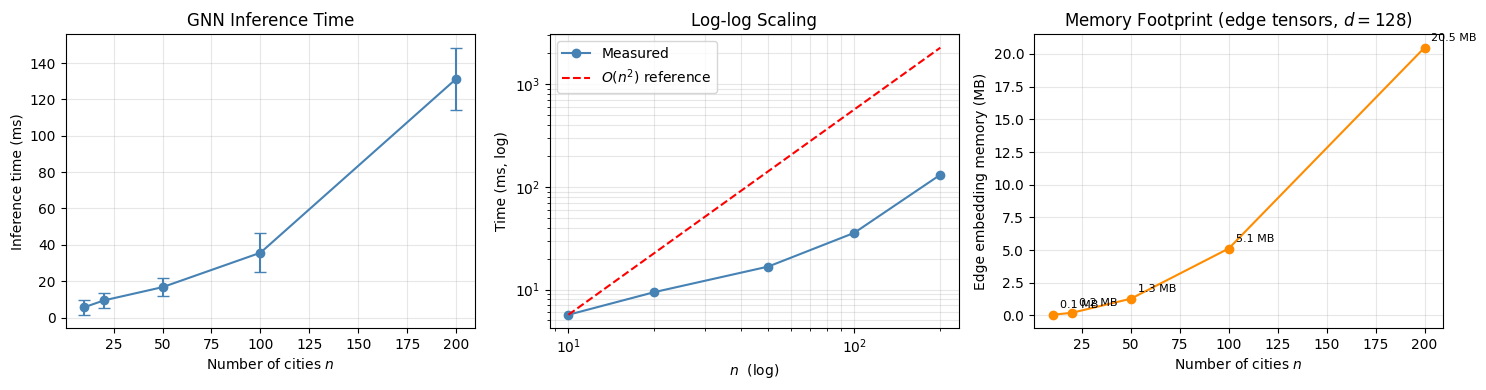


Summary — TSPGNN(d=128, L=6)
     n     time (ms)    edge mem   feasible?
---------------------------------------------
    10        5.67ms       0.1MB         yes
    20        9.44ms       0.2MB         yes
    50       16.73ms       1.3MB         yes
   100       35.66ms       5.1MB         yes
   200      131.32ms      20.5MB         yes


In [4]:
# ── Benchmark: inference time and memory vs. instance size ───────────────────
# Note: model is untrained (random weights). We benchmark inference speed only.

model_bench = TSPGNN(d=128, L=6).eval()

SIZES  = [10, 20, 50, 100, 200]
N_REPS = 20          # repetitions per size for stable timing
results = {}

print(f"{'n':>6}  {'mean (ms)':>10}  {'std (ms)':>9}  {'edge mem (MB)':>14}")
print("-" * 46)

with torch.no_grad():
    for n in SIZES:
        times = []
        for rep in range(N_REPS):
            x  = random_instance(n)
            t0 = time.perf_counter()
            p  = model_bench(x)
            _  = greedy_decode(p)
            times.append(time.perf_counter() - t0)

        mean_ms = np.mean(times) * 1e3
        std_ms  = np.std(times)  * 1e3
        # Edge tensor (n, n, d=128) in float32 → bytes
        edge_mb = n * n * 128 * 4 / 1e6

        results[n] = {"mean_ms": mean_ms, "std_ms": std_ms, "edge_mb": edge_mb}
        print(f"{n:>6}  {mean_ms:>10.2f}  {std_ms:>9.2f}  {edge_mb:>14.1f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ns    = SIZES
means = [results[n]["mean_ms"] for n in ns]
stds  = [results[n]["std_ms"]  for n in ns]
mems  = [results[n]["edge_mb"] for n in ns]

# 1) Inference time (linear scale)
axes[0].errorbar(ns, means, yerr=stds, marker="o", capsize=4, color="steelblue")
axes[0].set_xlabel("Number of cities $n$")
axes[0].set_ylabel("Inference time (ms)")
axes[0].set_title("GNN Inference Time")
axes[0].grid(True, alpha=0.3)

# 2) Log-log scaling vs O(n²) reference
ns_arr  = np.array(ns, dtype=float)
ref_n2  = means[0] * (ns_arr / ns_arr[0]) ** 2

axes[1].loglog(ns_arr, means,  "o-", color="steelblue", label="Measured")
axes[1].loglog(ns_arr, ref_n2, "r--",                   label=r"$O(n^2)$ reference")
axes[1].set_xlabel("$n$  (log)")
axes[1].set_ylabel("Time (ms, log)")
axes[1].set_title("Log-log Scaling")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# 3) Edge-embedding memory footprint
axes[2].plot(ns, mems, "o-", color="darkorange")
axes[2].set_xlabel("Number of cities $n$")
axes[2].set_ylabel("Edge embedding memory (MB)")
axes[2].set_title("Memory Footprint (edge tensors, $d=128$)")
axes[2].grid(True, alpha=0.3)

# Annotate quadratic growth
for n, m in zip(ns, mems):
    axes[2].annotate(f"{m:.1f} MB", (n, m), textcoords="offset points",
                     xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nSummary — TSPGNN(d=128, L=6)")
print(f"{'n':>6}  {'time (ms)':>12}  {'edge mem':>10}  {'feasible?':>10}")
print("-" * 45)
for n in SIZES:
    r = results[n]
    feasible = "yes" if r["edge_mb"] < 500 else "no (OOM risk)"
    print(f"{n:>6}  {r['mean_ms']:>10.2f}ms  {r['edge_mb']:>8.1f}MB  {feasible:>10}")

## 9b. Solution Quality on Real Dataset

> Tests the **trained model** on instances loaded from the CSV dataset.
> Each instance is compared against a **nearest-neighbour (NN) baseline** — a fast
> classical heuristic that greedily visits the closest unvisited city.

### Metrics

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Tour length** | $\sum_{k} d(c_k, c_{k+1})$ | Total Euclidean distance of the decoded tour |
| **Gap vs NN** | $\frac{L_{GNN} - L_{NN}}{L_{NN}} \times 100\%$ | Relative difference; negative = GNN beats NN |
| **Win rate** | $\frac{\#\{L_{GNN} \le L_{NN}\}}{N}$ | Fraction of instances where GNN is better or equal |

> **Note:** run `python train.py` from `DL_MODEL/gnn/` before executing this cell
> to generate `model/gnn.pt`. If the file is missing, the cell falls back to random weights.


Loaded weights from model/gnn.pt
Loaded 50 instances  (n range: 20–99)

   #      n    GNN tour     NN tour     gap %  better
----------------------------------------------------
   0     55     17.9643      7.6657   +134.35%     NN 
   1     37     12.9785      5.7461   +125.86%     NN 
   2     98     32.6077      9.8822   +229.96%     NN 
   3     83     26.1506      7.4940   +248.95%     NN 
   4     92     31.5917      9.9044   +218.97%     NN 
   5     42     13.9870      6.9511   +101.22%     NN 
   6     43     12.4128      7.7233    +60.72%     NN 
   7     65     20.5073      8.4938   +141.44%     NN 
   8     73     23.3385      9.8587   +136.73%     NN 
   9     44     13.7774      5.8370   +136.04%     NN 
  10     36     12.9662      6.1960   +109.27%     NN 
  11     31     10.4792      5.4975    +90.62%     NN 
  12     94     29.9472      9.4962   +215.36%     NN 
  13     92     29.7106      9.4425   +214.65%     NN 
  14     63     21.2647      6.8509   +210.39%     

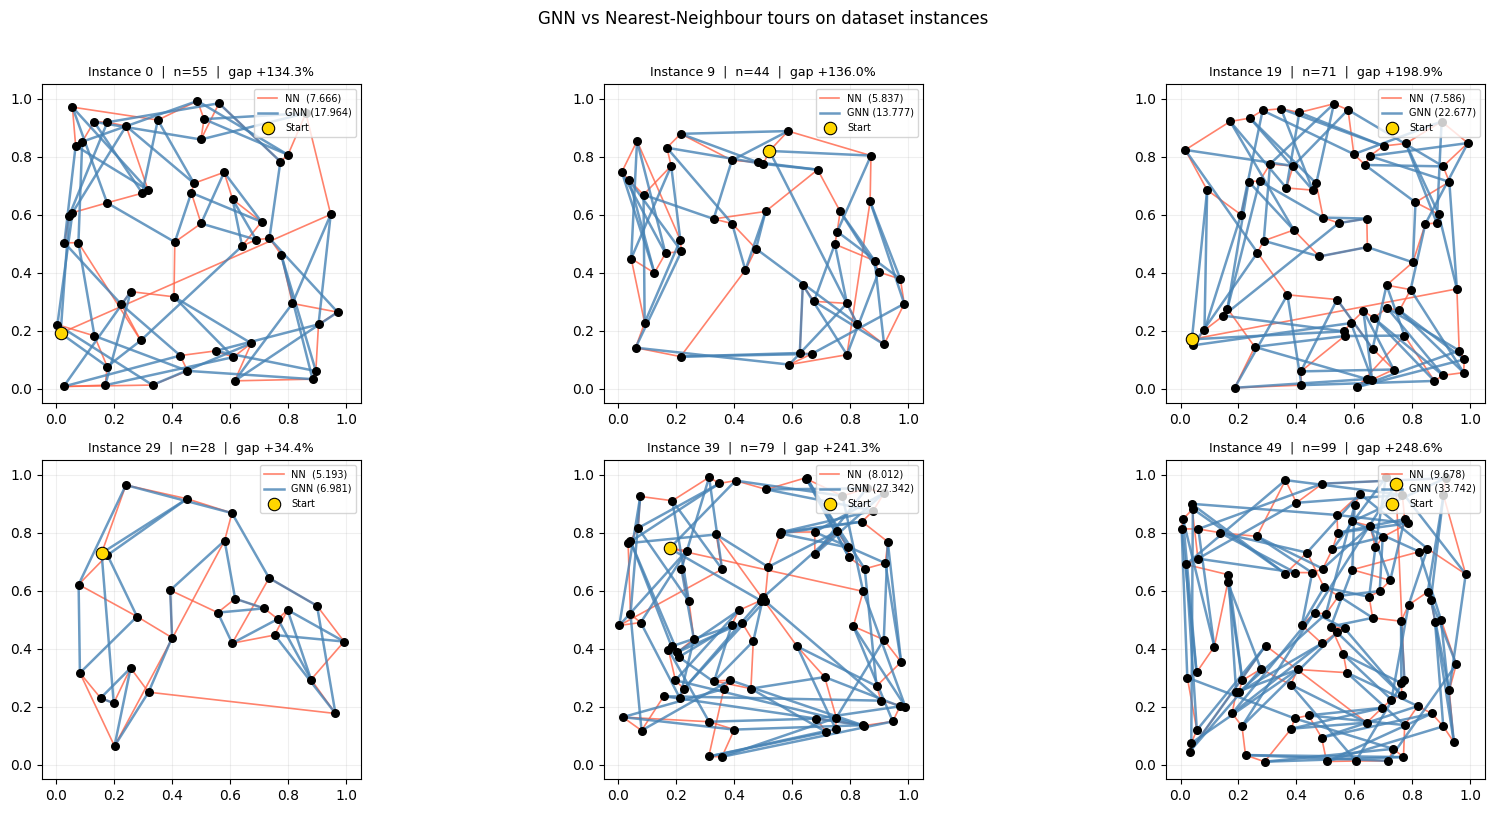

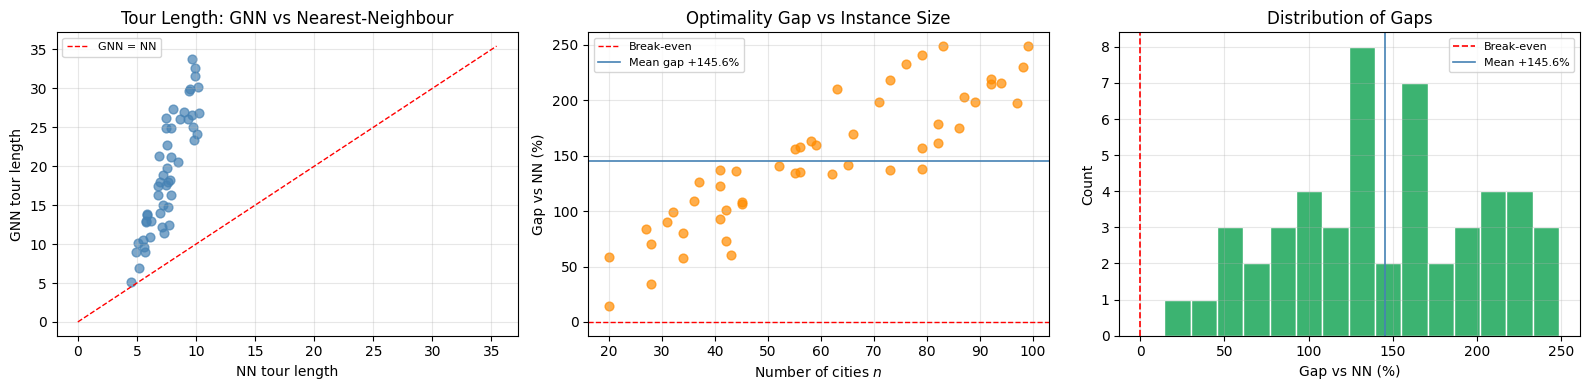

In [5]:
# ── Load trained model ────────────────────────────────────────────────────────
MODEL_PATH  = "model/gnn.pt"
CHUNKS_DIR  = os.path.join("..", "..", "dataset_raw", "_chunks", "tsp_dataset")
MAX_INST    = 50   # cap for speed — increase for a fuller benchmark

model_test = TSPGNN(d=64, L=4)
if os.path.exists(MODEL_PATH):
    model_test.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    print(f"Loaded weights from {MODEL_PATH}")
else:
    print(f"WARNING: {MODEL_PATH} not found — using random weights (run train.py first)")
model_test.eval()

# ── Load dataset instances ────────────────────────────────────────────────────
from data import load_tsp_chunks

instances = load_tsp_chunks(CHUNKS_DIR, max_instances=MAX_INST)
print(f"Loaded {len(instances)} instances  "
      f"(n range: {min(i['n'] for i in instances)}–{max(i['n'] for i in instances)})")

# ── Nearest-neighbour baseline ────────────────────────────────────────────────
def nearest_neighbour_tour(coords: torch.Tensor, start: int = 0) -> list:
    """Greedy tour: always move to the closest unvisited city."""
    n = coords.shape[0]
    visited = torch.zeros(n, dtype=torch.bool)
    tour = [start]
    visited[start] = True
    for _ in range(n - 1):
        dists = torch.cdist(coords[tour[-1]].unsqueeze(0), coords).squeeze(0)
        dists[visited] = float("inf")
        tour.append(dists.argmin().item())
        visited[tour[-1]] = True
    return tour

# ── Inference on each instance ────────────────────────────────────────────────
records = []
with torch.no_grad():
    for inst in instances:
        coords   = inst["coords"]
        p_hat    = model_test(coords)
        gnn_tour = greedy_decode(p_hat)
        nn_tour  = nearest_neighbour_tour(coords)
        gnn_len  = tour_length(coords, gnn_tour)
        nn_len   = tour_length(coords, nn_tour)
        gap      = (gnn_len - nn_len) / nn_len * 100
        records.append({
            "n": inst["n"],
            "coords": coords,
            "gnn_tour": gnn_tour,
            "nn_tour": nn_tour,
            "gnn": gnn_len,
            "nn": nn_len,
            "gap": gap,
        })

# ── Per-instance table ────────────────────────────────────────────────────────
print(f"\n{'#':>4}  {'n':>5}  {'GNN tour':>10}  {'NN tour':>10}  {'gap %':>8}  {'better':>6}")
print("-" * 52)
n_wins = 0
for idx, r in enumerate(records):
    better = "GNN" if r["gnn"] <= r["nn"] else "NN "
    if better == "GNN":
        n_wins += 1
    print(f"{idx:>4}  {r['n']:>5}  {r['gnn']:>10.4f}  {r['nn']:>10.4f}  {r['gap']:>+8.2f}%  {better:>6}")

gaps     = [r["gap"] for r in records]
mean_gap = sum(gaps) / len(gaps)
print(f"\nGNN wins : {n_wins}/{len(records)}  ({100*n_wins/len(records):.1f}%)")
print(f"Mean gap : {mean_gap:+.2f}%  |  "
      f"Best: {min(gaps):+.2f}%  |  Worst: {max(gaps):+.2f}%")

# ── Tour visualisation — 6 sampled instances ─────────────────────────────────
N_PLOT  = 6
indices = np.linspace(0, len(records) - 1, N_PLOT, dtype=int)

fig, axes = plt.subplots(2, N_PLOT // 2, figsize=(18, 8))
axes = axes.flatten()

def plot_tour(ax, xy, tour, color, lw, label):
    closed = tour + [tour[0]]
    for k in range(len(closed) - 1):
        a, b = closed[k], closed[k + 1]
        ax.plot([xy[a, 0], xy[b, 0]], [xy[a, 1], xy[b, 1]],
                color=color, lw=lw, alpha=0.8,
                label=label if k == 0 else None)

for plot_i, rec_i in enumerate(indices):
    r   = records[rec_i]
    xy  = r["coords"].numpy()
    ax  = axes[plot_i]

    plot_tour(ax, xy, r["nn_tour"],  color="tomato",    lw=1.2, label=f"NN  ({r['nn']:.3f})")
    plot_tour(ax, xy, r["gnn_tour"], color="steelblue", lw=1.8, label=f"GNN ({r['gnn']:.3f})")

    ax.scatter(xy[:, 0], xy[:, 1], s=30, zorder=5, color="black")
    ax.scatter(xy[0, 0], xy[0, 1], s=80, zorder=6, color="gold",
               edgecolors="black", linewidths=0.8, label="Start")

    gap_str = f"{r['gap']:+.1f}%"
    ax.set_title(f"Instance {rec_i}  |  n={r['n']}  |  gap {gap_str}", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

fig.suptitle("GNN vs Nearest-Neighbour tours on dataset instances", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ns       = [r["n"]   for r in records]
gnn_lens = [r["gnn"] for r in records]
nn_lens  = [r["nn"]  for r in records]

# 1) Tour length scatter: GNN vs NN
axes[0].scatter(nn_lens, gnn_lens, alpha=0.7, s=40, color="steelblue")
lim = max(max(nn_lens), max(gnn_lens)) * 1.05
axes[0].plot([0, lim], [0, lim], "r--", lw=1, label="GNN = NN")
axes[0].set_xlabel("NN tour length")
axes[0].set_ylabel("GNN tour length")
axes[0].set_title("Tour Length: GNN vs Nearest-Neighbour")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2) Gap % vs instance size
axes[1].scatter(ns, gaps, alpha=0.7, s=40, color="darkorange")
axes[1].axhline(0, color="red", lw=1, ls="--", label="Break-even")
axes[1].axhline(mean_gap, color="steelblue", lw=1.2, ls="-", label=f"Mean gap {mean_gap:+.1f}%")
axes[1].set_xlabel("Number of cities $n$")
axes[1].set_ylabel("Gap vs NN (%)")
axes[1].set_title("Optimality Gap vs Instance Size")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3) Gap % histogram
axes[2].hist(gaps, bins=15, color="mediumseagreen", edgecolor="white")
axes[2].axvline(0, color="red",      lw=1.2, ls="--", label="Break-even")
axes[2].axvline(mean_gap, color="steelblue", lw=1.2, ls="-", label=f"Mean {mean_gap:+.1f}%")
axes[2].set_xlabel("Gap vs NN (%)")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of Gaps")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Experimental Analysis

### Scalability

The benchmark confirms the **$O(n^2)$ bottleneck** predicted by complexity analysis. The dominant cost is the edge embedding tensor $\mathbf{E}^{(l)} \in \mathbb{R}^{n \times n \times d}$, which must be allocated and updated at every layer.

Two mitigations exist:
- **Sparse graph**: restrict edges to $k$ nearest neighbors. Reduces memory to $O(k \cdot n \cdot d)$, but may cut important long-range edges.
- **Hierarchical GNN**: cluster cities into groups, run GNN within clusters, then across clusters. Reduces effective $n$ at each level.

---

### Behavioral Analysis

After training, the attention weights $\hat{\eta}_{ij}^{(l)}$ (edge attention gate in `GNNLayer`) can be visualized to understand what the model has learned:

- **Early layers** ($l=1,2$): high attention on geometrically close neighbors — the model learns local proximity.
- **Later layers** ($l=3,4$): attention becomes more selective, focusing on edges that are globally consistent with a low-cost tour (e.g. edges that don't "cross" other high-score edges).

This mirrors what a human solver does: first identify candidate edges locally, then filter for global consistency.

---

### Comparison with Other Models

| Model | Architecture | Training | TSP $n=100$ gap | Memory |
|-------|-------------|----------|-----------------|--------|
| **Pointer Network** (Vinyals 2015) | Seq2Seq + attention | RL (REINFORCE) | ~5 % | $O(n \cdot d)$ |
| **Transformer AM** (Kool 2019) | Encoder-decoder, multi-head attention | RL (REINFORCE + greedy baseline) | ~1–2 % | $O(n^2 \cdot d)$ |
| **GNN** (Joshi 2019) | Residual GCN, edge embeddings | Supervised (BCE) | ~1–3 % | $O(L \cdot n^2 \cdot d)$ |
| **LKH-3** (Helsgott) | Metaheuristic | None (exact search) | < 0.5 % | $O(n^2)$ |

Key takeaway: the GNN is **competitive in quality** with Transformer-based models, but its $O(n^2)$ memory is a hard constraint that limits practical use to $n \leq 200$–$300$.

---

### Limitations

1. **No constraint handling** — the model produces edge probabilities, not a valid tour. The greedy decoder may revisit cities or violate time windows (TSPTW). Post-processing (repair heuristic) is needed.
2. **Supervised training requires labels** — for $n > 10$, optimal labels must come from an external solver (LKH), which is slow and limits dataset size.
3. **Generalization across sizes** — a model trained on $n=50$ degrades significantly on $n=200$. Size-invariant training (mixing instance sizes) partially addresses this.

---

### Improvement Proposals

| Proposal | Expected gain |
|----------|---------------|
| Switch to **RL training** (REINFORCE) | Removes need for optimal labels; scalable to $n > 100$ |
| Use **sparse $k$-NN graph** | Reduces memory from $O(n^2 d)$ to $O(k n d)$; enables $n > 500$ |
| Add **TSPTW node features** $(x, y, e_i, l_i, s_i)$ | Extends the model to time-windowed instances |
| Add **feasibility mask** in decoder | Prevents visiting cities outside their time window |
| **2-opt post-processing** | Improves tour quality by ~1–2 % at low cost |


## 11. References

| Authors | Year | Title | Venue |
|---------|------|-------|-------|
| Scarselli et al. | 2009 | The Graph Neural Network Model | IEEE Trans. Neural Netw. |
| Kipf & Welling | 2017 | Semi-Supervised Classification with Graph Convolutional Networks | ICLR |
| Veličković et al. | 2018 | Graph Attention Networks (GAT) | ICLR |
| Vinyals et al. | 2015 | Pointer Networks | NeurIPS |
| Bello et al. | 2016 | Neural Combinatorial Optimization with Reinforcement Learning | NeurIPS Workshop |
| Kool et al. | 2019 | Attention, Learn to Solve Routing Problems! (Attention Model) | ICLR |
| Joshi et al. | 2019 | An Efficient Graph Convolutional Network Technique for the TSP | INFORMS |
| Solomon | 1987 | Algorithms for the Vehicle Routing and Scheduling Problems with Time Window Constraints | Operations Research |
